# 09 Memory-Anchored OT Matching W1

역할: clean normal에서 prototype별 patch-bag memory와 prototype-level spatial graph를 구축하고, clean self-probe 한 장을 raw DINO patch query로 넣어 memory-anchored unbalanced OT matching이 합리적으로 낮은 anomaly decomposition을 내는지 확인한다.

W1 범위에서는 anomaly AUROC, shifted/anomaly batch evaluation, learnable head, instance-level graph를 구현하지 않는다.


## Cell Role: Repo Setup

Colab에서는 `/content/ReGraM` checkout을 사용하고, 로컬에서는 현재 repo root를 찾는다. W1 모듈은 `src/stage1_adapter/memory_bank.py`와 `src/stage1_adapter/memory_ot_matcher.py`에 있다.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import os
import shutil
import subprocess
import sys

import pandas as pd
from IPython.display import display

REPO_URL = 'https://github.com/outSeop/ReGraM.git'


def is_regram_root(path: Path) -> bool:
    return (
        (path / 'experiments' / 'validation' / 'condition_shift_baseline').exists()
        and (path / 'manifests').exists()
    )


colab_checkout = Path('/content/ReGraM')
if Path('/content').exists():
    if (colab_checkout / '.git').exists():
        subprocess.run(['git', '-C', str(colab_checkout), 'fetch', 'origin', 'main'], check=True)
        subprocess.run(
            [
                'git', '-C', str(colab_checkout), 'checkout', 'FETCH_HEAD', '--',
                'experiments/validation/condition_shift_baseline/src',
                'experiments/validation/condition_shift_baseline/notebook/09_memory_anchored_ot_matching.ipynb',
            ],
            check=True,
        )
    else:
        subprocess.run(['git', 'clone', REPO_URL, str(colab_checkout)], check=True)

cwd = Path.cwd().resolve()
repo_candidates = [colab_checkout, cwd, *cwd.parents]
REPO_ROOT = next((candidate.resolve() for candidate in repo_candidates if candidate.exists() and is_regram_root(candidate)), None)
if REPO_ROOT is None:
    raise FileNotFoundError('ReGraM checkout not found')

EXP_ROOT = REPO_ROOT / 'experiments' / 'validation' / 'condition_shift_baseline'
SRC_ROOT = EXP_ROOT / 'src'
for import_root in [SRC_ROOT, SRC_ROOT / 'orchestration']:
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

print('REPO_ROOT =', REPO_ROOT)
print('EXP_ROOT =', EXP_ROOT)


REPO_ROOT = /content/ReGraM
EXP_ROOT = /content/ReGraM/experiments/validation/condition_shift_baseline


## Cell Role: Settings And Data Readiness

W1은 `breakfast_box` clean normal 소수 샘플만 사용한다. `PROBE_SAMPLE_ID`는 memory source에서 제외해 clean self-probe query로 사용한다.


In [2]:
CATEGORY = 'breakfast_box'
MEMORY_SAMPLE_IDS = ['000.png', '001.png', '002.png', '004.png', '005.png']
PROBE_SAMPLE_ID = '003.png'
FEATURE_BACKBONE = 'dinov2_vits14'
IMAGE_SIZE = 224
MAX_PROTOTYPES = 8
MIN_PAIRS_FOR_SPATIAL_EDGE = 3

RAW_LOCO_ROW_ROOT = REPO_ROOT / 'data' / 'row'
RAW_LOCO_ROOT = RAW_LOCO_ROW_ROOT / 'mvtec_loco_anomaly_detection'
GROUNDING_MASK_ROOT = REPO_ROOT / 'external' / 'UniVAD' / 'masks' / 'mvtec_loco_caption'
PROBE_ROOT = EXP_ROOT / 'reports' / 'memory_anchored_ot_matching'
MEMORY_JSON = PROBE_ROOT / f'{CATEGORY}_w1_memory_bank_summary.json'
SELF_PROBE_JSON = PROBE_ROOT / f'{CATEGORY}_w1_clean_self_probe.json'
PROBE_ROOT.mkdir(parents=True, exist_ok=True)

DRIVE_RAW_TAR = Path('/content/drive/MyDrive/ReGraM/data/row/mvtec_loco_anomaly_detection.tar.gz')
DRIVE_MASK_ROOT = Path('/content/drive/MyDrive/ReGraM/univad_masks/mvtec_loco_caption')


def mount_drive_if_available() -> None:
    if not Path('/content').exists() or Path('/content/drive/MyDrive').exists():
        return
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as exc:
        print(f'Google Drive mount skipped: {type(exc).__name__}: {exc}')


def normalize_dataset_root(parent: Path, dataset_name: str) -> Path:
    direct = parent / dataset_name
    nested_candidates = [parent / 'content' / dataset_name, parent / 'data' / 'row' / dataset_name]
    if direct.exists():
        return direct
    for candidate in nested_candidates:
        if candidate.exists():
            direct.parent.mkdir(parents=True, exist_ok=True)
            print(f'normalize dataset root: {candidate} -> {direct}')
            shutil.move(str(candidate), str(direct))
            return direct
    return direct


def restore_raw_loco_from_drive_if_needed() -> None:
    global RAW_LOCO_ROOT
    RAW_LOCO_ROOT = normalize_dataset_root(RAW_LOCO_ROW_ROOT, 'mvtec_loco_anomaly_detection')
    if (RAW_LOCO_ROOT / CATEGORY / 'test' / 'good').exists():
        return
    mount_drive_if_available()
    if not DRIVE_RAW_TAR.exists():
        print(f'raw LOCO Drive tar not found: {DRIVE_RAW_TAR}')
        return
    RAW_LOCO_ROW_ROOT.mkdir(parents=True, exist_ok=True)
    print(f'extract raw LOCO from Drive: {DRIVE_RAW_TAR} -> {RAW_LOCO_ROW_ROOT}')
    subprocess.run(['tar', '-xf', str(DRIVE_RAW_TAR), '-C', str(RAW_LOCO_ROW_ROOT)], check=True)
    RAW_LOCO_ROOT = normalize_dataset_root(RAW_LOCO_ROW_ROOT, 'mvtec_loco_anomaly_detection')


def clean_image_path(image_id: str) -> Path:
    return RAW_LOCO_ROOT / CATEGORY / 'test' / 'good' / image_id


def clean_mask_path(image_id: str) -> Path:
    return GROUNDING_MASK_ROOT / CATEGORY / 'test' / 'good' / Path(image_id).stem / 'grounding_mask.png'


def restore_clean_masks_from_drive_if_needed(image_ids: list[str]) -> None:
    missing = [image_id for image_id in image_ids if not clean_mask_path(image_id).exists()]
    if not missing:
        return
    mount_drive_if_available()
    category_drive_root = DRIVE_MASK_ROOT / CATEGORY
    category_session_root = GROUNDING_MASK_ROOT / CATEGORY
    if category_drive_root.exists() and not category_session_root.exists():
        category_session_root.parent.mkdir(parents=True, exist_ok=True)
        print(f'restore masks category from Drive: {category_drive_root} -> {category_session_root}')
        shutil.copytree(category_drive_root, category_session_root, dirs_exist_ok=True)
    for image_id in missing:
        session_mask = clean_mask_path(image_id)
        drive_candidates = [
            category_drive_root / 'test' / 'good' / Path(image_id).stem / 'grounding_mask.png',
            category_drive_root / Path(image_id).stem / 'grounding_mask.png',
        ]
        drive_mask = next((candidate for candidate in drive_candidates if candidate.exists()), None)
        if drive_mask is None:
            continue
        session_mask.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(drive_mask, session_mask)


restore_raw_loco_from_drive_if_needed()
all_required_ids = MEMORY_SAMPLE_IDS + [PROBE_SAMPLE_ID]
restore_clean_masks_from_drive_if_needed(all_required_ids)
missing = {
    image_id: {'image': clean_image_path(image_id), 'mask': clean_mask_path(image_id)}
    for image_id in all_required_ids
    if not clean_image_path(image_id).exists() or not clean_mask_path(image_id).exists()
}
if missing:
    raise FileNotFoundError(f'Missing W1 clean image/mask inputs: {missing}')

settings_df = pd.DataFrame([
    {
        'category': CATEGORY,
        'memory_sample_ids': ', '.join(MEMORY_SAMPLE_IDS),
        'probe_sample_id': PROBE_SAMPLE_ID,
        'feature_backbone': FEATURE_BACKBONE,
        'image_size': IMAGE_SIZE,
        'max_prototypes': MAX_PROTOTYPES,
        'memory_json': str(MEMORY_JSON),
        'self_probe_json': str(SELF_PROBE_JSON),
    }
])
display(settings_df)


,category,memory_sample_ids,probe_sample_id,feature_backbone,image_size,max_prototypes,memory_json,self_probe_json
0,breakfast_box,"000.png, 001.png, 002.png, 004.png, 005.png",003.png,dinov2_vits14,224,8,/content/ReGraM/experiments/validation/conditi...,/content/ReGraM/experiments/validation/conditi...


## Cell Role: DINO And Dependency Setup

DINOv2 patch feature extractor를 준비한다. POT가 없으면 설치 후 런타임 재시작 없이 import를 다시 시도한다.


In [3]:
import importlib.util
import numpy as np
import torch
from PIL import Image

if importlib.util.find_spec('ot') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pot'], check=True)

import ot  # noqa: F401

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

dino_model = torch.hub.load('facebookresearch/dinov2', FEATURE_BACKBONE).to(device).eval()
dino_mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32, device=device).view(1, 3, 1, 1)
dino_std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32, device=device).view(1, 3, 1, 1)


def preprocess_dino(image: Image.Image) -> torch.Tensor:
    image = image.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.Resampling.BICUBIC)
    array = np.asarray(image, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(array).permute(2, 0, 1).unsqueeze(0).to(device)
    return (tensor - dino_mean) / dino_std


@torch.no_grad()
def extract_dino_feature_map(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert('RGB')
    output = dino_model.forward_features(preprocess_dino(image))
    tokens = output['x_norm_patchtokens'] if isinstance(output, dict) else output
    tokens = tokens.squeeze(0).detach().cpu().float()
    grid = int(math.sqrt(tokens.shape[0]))
    if grid * grid != tokens.shape[0]:
        raise ValueError(f'DINO token count is not square: {tokens.shape[0]}')
    return tokens.reshape(grid, grid, tokens.shape[-1]).numpy()

print('DINO backbone ready:', FEATURE_BACKBONE)


device = cuda


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINO backbone ready: dinov2_vits14


## Cell Role: Build Memory Bank

clean memory image의 normalized mask를 patch-bag instance로 변환하고, clean descriptor clustering으로 prototype memory와 prototype-level spatial graph를 만든다.


In [4]:
from graph_probe.component_io import save_json
from relation.grounding_mask_cluster import raw_masks_from_label_image
from stage1_adapter import (
    CandidateMaskNormalizationConfig,
    MatchingConfig,
    build_memory_bank,
    memory_bank_summary,
    normalize_candidate_masks,
)

MASK_NORMALIZATION_CONFIG = CandidateMaskNormalizationConfig(
    max_mask_area_ratio=0.30,
    min_mask_area_ratio=0.001,
    small_cluster_area_ratio=0.006,
    min_cluster_members=3,
    min_cluster_union_area_ratio=0.004,
    max_cluster_union_area_ratio=0.25,
    max_centroid_dist_ratio=0.10,
    max_bbox_gap_ratio=0.04,
)


def normalized_masks_loader(mask_path: Path, image_shape: tuple[int, int]) -> list[dict]:
    raw_masks = raw_masks_from_label_image(Image.open(mask_path).convert('RGB'))
    normalized_masks, _ = normalize_candidate_masks(
        raw_masks,
        image_shape=image_shape,
        config=MASK_NORMALIZATION_CONFIG,
    )
    return normalized_masks

memory_image_paths = [clean_image_path(image_id) for image_id in MEMORY_SAMPLE_IDS]
memory_mask_paths = [clean_mask_path(image_id) for image_id in MEMORY_SAMPLE_IDS]

memory = build_memory_bank(
    memory_image_paths,
    memory_mask_paths,
    feature_extractor=extract_dino_feature_map,
    raw_masks_loader=normalized_masks_loader,
    image_size=IMAGE_SIZE,
    feature_backbone=FEATURE_BACKBONE,
    max_prototypes=MAX_PROTOTYPES,
    normalization_config=MASK_NORMALIZATION_CONFIG,
    min_pairs_for_spatial_edge=MIN_PAIRS_FOR_SPATIAL_EDGE,
    category=CATEGORY,
)

memory_summary = memory_bank_summary(memory)
save_json(memory.to_metadata_dict(), MEMORY_JSON)
print(f'saved memory summary: {MEMORY_JSON}')
display(pd.DataFrame([memory_summary]))
display(
    pd.DataFrame([
        {
            'prototype_id': prototype_id,
            'num_instances': len(entry.instances),
            'occurrence_rate': entry.occurrence_rate,
            'expected_instance_count': entry.expected_instance_count,
            'within_variance': entry.within_variance,
            'q10': entry.within_sim_quantiles.get(0.10),
            'q20': entry.within_sim_quantiles.get(0.20),
            'q50': entry.within_sim_quantiles.get(0.50),
        }
        for prototype_id, entry in memory.prototypes.items()
    ])
)


saved memory summary: /content/ReGraM/experiments/validation/condition_shift_baseline/reports/memory_anchored_ot_matching/breakfast_box_w1_memory_bank_summary.json


,category,num_source_images,num_prototypes,num_spatial_edges,prototype_instance_counts,prototype_occurrence_rates
0,breakfast_box,5,8,19,"{'prototype_000': 9, 'prototype_001': 7, 'prot...","{'prototype_000': 1.0, 'prototype_001': 0.6, '..."


,prototype_id,num_instances,occurrence_rate,expected_instance_count,within_variance,q10,q20,q50
0,prototype_000,9,1.0,1.800000,4.558330e-05,0.966208,0.969777,0.972070
1,prototype_001,7,0.6,2.333333,5.298351e-04,0.920277,0.941247,0.950381
2,prototype_002,6,1.0,1.200000,3.398439e-04,0.925143,0.942534,0.945412
3,prototype_003,5,1.0,1.000000,9.623602e-05,0.958637,0.959298,0.964854
4,prototype_004,4,0.4,2.000000,1.583955e-04,0.937691,0.943894,0.955658
5,prototype_005,4,0.8,1.000000,1.684518e-04,0.920446,0.925345,0.936675
6,prototype_006,2,0.4,1.000000,5.792427e-06,0.931067,0.931549,0.932993
7,prototype_007,2,0.4,1.000000,6.183706e-08,0.967838,0.967888,0.968037


## Cell Role: Visualize Memory Spatial Graph

prototype별 clean centroid와 spatial edge의 평균 Δposition을 확인한다. W1에서는 prototype-level spatial graph만 사용한다.


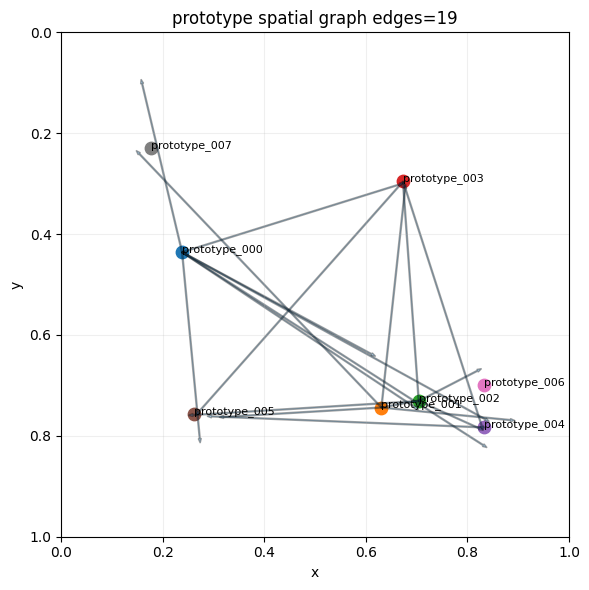

,prototype_i,prototype_j,dx_mean,dy_mean,num_pairs
0,prototype_000,prototype_001,0.381198,0.206481,13
1,prototype_000,prototype_002,0.465752,0.312388,11
2,prototype_000,prototype_003,0.437362,-0.137159,9
3,prototype_000,prototype_004,0.600649,0.387446,7
4,prototype_000,prototype_005,0.035660,0.378366,7
5,prototype_000,prototype_006,0.605087,0.335606,4
6,prototype_000,prototype_007,-0.080841,-0.342968,3
7,prototype_001,prototype_002,0.082466,-0.015629,7
8,prototype_001,prototype_003,0.047614,-0.443050,7
9,prototype_001,prototype_004,0.262857,0.025714,7


In [5]:
import matplotlib.pyplot as plt

prototype_centroids = {
    prototype_id: np.mean([instance.centroid_pos for instance in entry.instances], axis=0)
    for prototype_id, entry in memory.prototypes.items()
}
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
for prototype_id, centroid in prototype_centroids.items():
    ax.scatter(centroid[0], centroid[1], s=80)
    ax.text(centroid[0], centroid[1], prototype_id, fontsize=8)
for (proto_i, proto_j), edge in memory.spatial_graph.items():
    start = prototype_centroids.get(proto_i)
    if start is None:
        continue
    delta = edge.delta_pos_mean
    ax.arrow(start[0], start[1], delta[0], delta[1], width=0.002, alpha=0.35, length_includes_head=True)
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)
ax.set_title(f'prototype spatial graph edges={len(memory.spatial_graph)}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

edge_df = pd.DataFrame([
    {
        'prototype_i': edge.prototype_i,
        'prototype_j': edge.prototype_j,
        'dx_mean': edge.delta_pos_mean[0],
        'dy_mean': edge.delta_pos_mean[1],
        'num_pairs': edge.num_pairs,
    }
    for edge in memory.spatial_graph.values()
])
display(edge_df)


## Cell Role: Visualize Prototype Patch Memory

prototype별 clean memory patch-bag이 이미지 grid의 어느 영역을 차지하는지 본다. 이 뷰는 segmentation mask 품질이 아니라 memory가 어떤 normal role support를 기억하고 있는지 확인하기 위한 것이다.


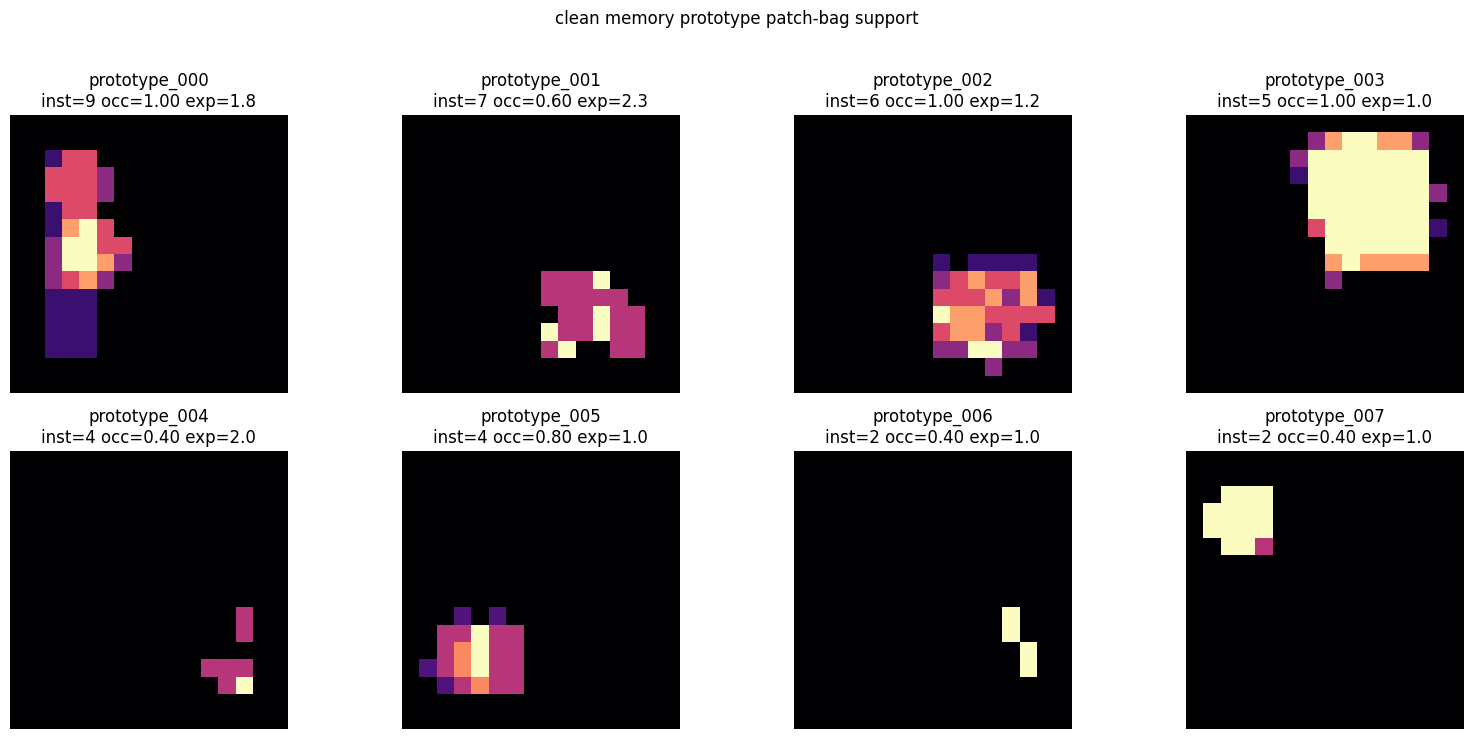

In [6]:
def patch_positions_to_grid(positions: np.ndarray, grid_shape: tuple[int, int]) -> np.ndarray:
    grid = np.zeros(grid_shape, dtype=np.float32)
    if positions.size == 0:
        return grid
    xs = np.clip(np.rint(positions[:, 0] * max(grid_shape[1] - 1, 1)).astype(int), 0, grid_shape[1] - 1)
    ys = np.clip(np.rint(positions[:, 1] * max(grid_shape[0] - 1, 1)).astype(int), 0, grid_shape[0] - 1)
    for y, x in zip(ys, xs):
        grid[y, x] += 1.0
    if grid.max() > 0:
        grid /= grid.max()
    return grid


def prototype_support_grid(entry, grid_shape: tuple[int, int]) -> np.ndarray:
    grids = [patch_positions_to_grid(instance.patch_positions, grid_shape) for instance in entry.instances]
    if not grids:
        return np.zeros(grid_shape, dtype=np.float32)
    support = np.mean(np.stack(grids, axis=0), axis=0)
    if support.max() > 0:
        support /= support.max()
    return support

feature_grid_shape = next(iter(memory.prototypes.values())).instances[0].patch_features.shape[0]
query_grid_shape = query_feature_map.shape[:2] if 'query_feature_map' in globals() else extract_dino_feature_map(clean_image_path(PROBE_SAMPLE_ID)).shape[:2]
num_cols = min(4, max(1, len(memory.prototypes)))
num_rows = int(math.ceil(len(memory.prototypes) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3.6 * num_rows))
axes = np.asarray(axes).reshape(-1)
for ax, (prototype_id, entry) in zip(axes, memory.prototypes.items()):
    support = prototype_support_grid(entry, query_grid_shape)
    im = ax.imshow(support, cmap='magma', vmin=0, vmax=1)
    ax.set_title(
        f"{prototype_id}\ninst={len(entry.instances)} occ={entry.occurrence_rate:.2f} exp={entry.expected_instance_count:.1f}"
    )
    ax.axis('off')
for ax in axes[len(memory.prototypes):]:
    ax.axis('off')
fig.suptitle('clean memory prototype patch-bag support', y=1.02)
plt.tight_layout()
plt.show()


## Cell Role: Clean Self-Probe Inference

memory에 들어가지 않은 clean normal 한 장을 query로 넣는다. Query는 raw DINO patch만 사용하며, query-side SAM mask를 사용하지 않는다.


In [7]:
from stage1_adapter import (
    decomposition_summary,
    match_query_against_memory,
    query_patch_grid_from_feature_map,
)

matching_config = MatchingConfig(
    assignment_mode='top_k',
    top_k_prototypes=3,
    min_assignment_similarity=0.5,
    soft_assign_quantile=0.20,  # used only when assignment_mode='threshold'
    ot_reg=0.05,
    ot_marginal_penalty=1.0,
    min_matched_mass_for_instance=0.5,
    skip_signal_4_if_no_extent=True,
    spatial_signal_mode='clipped_l2',
    spatial_min_occurrence_rate=0.8,
    spatial_min_expected_count=0.7,
    spatial_max_expected_count=1.3,
    spatial_min_edge_pairs=5,
    spatial_edge_tolerance=0.05,
    spatial_edge_cap=3.0,
)

query_feature_map = extract_dino_feature_map(clean_image_path(PROBE_SAMPLE_ID))
query_patch_features, query_patch_positions = query_patch_grid_from_feature_map(query_feature_map)
result = match_query_against_memory(
    query_patch_features=query_patch_features,
    query_patch_positions=query_patch_positions,
    memory=memory,
    config=matching_config,
)
save_json(result.to_metadata_dict(), SELF_PROBE_JSON)
print(f'saved self-probe result: {SELF_PROBE_JSON}')
display(pd.DataFrame([decomposition_summary(result)]))
per_proto_df = pd.DataFrame([
    value.to_metadata_dict()
    for value in result.per_prototype.values()
]).drop(columns=['transport_shape', 'debug'], errors='ignore')
display(per_proto_df)
display(pd.DataFrame([result.debug.get('spatial', {})]).drop(columns=['skipped_edges'], errors='ignore'))


saved self-probe result: /content/ReGraM/experiments/validation/condition_shift_baseline/reports/memory_anchored_ot_matching/breakfast_box_w1_clean_self_probe.json


,signal_1_total,signal_2_total,signal_3_total,signal_4_total,total,num_spatial_violations,num_prototypes
0,1.013254,1.013254,0.0,169.495304,171.521811,19,8


,prototype_id,query_mass,memory_mass,matching_cost,unmatched_query_mass,unmatched_memory_mass,matched_instance_count,matched_instance_count_per_image,expected_instance_count,instance_count_diff,matched_extent
0,prototype_000,1.0,1.0,0.143909,0.099191,0.099191,9,1.800000,1.800000,0.0,"[0.23658358750980535, 0.4884237048094916]"
1,prototype_001,1.0,1.0,0.262813,0.150806,0.150806,7,2.333333,2.333333,0.0,"[0.7139421335521032, 0.599025227291573]"
2,prototype_002,1.0,1.0,0.270147,0.162512,0.162512,6,1.200000,1.200000,0.0,"[0.703594151984704, 0.49829983880639733]"
3,prototype_003,1.0,1.0,0.143055,0.086447,0.086447,5,1.000000,1.000000,0.0,"[0.6835795530978692, 0.34581673328700185]"
4,prototype_004,1.0,1.0,0.219440,0.117346,0.117346,4,2.000000,2.000000,0.0,"[0.7252914890334101, 0.7304328117170554]"
5,prototype_005,1.0,1.0,0.207546,0.130002,0.130002,4,1.000000,1.000000,0.0,"[0.229596210990923, 0.49965351258214286]"
6,prototype_006,1.0,1.0,0.220148,0.121054,0.121054,2,1.000000,1.000000,0.0,"[0.6342665765310421, 0.6871822546569354]"
7,prototype_007,1.0,1.0,0.248913,0.145896,0.145896,2,1.000000,1.000000,0.0,"[0.22031696363342715, 0.47325135291618675]"


## Cell Role: Visualize Self-Probe Query Matching

clean self-probe query에서 prototype별 soft assignment heatmap, active patch mask, matched extent, signal breakdown을 본다. Query-side SAM은 사용하지 않고 raw DINO patch만 사용한다.


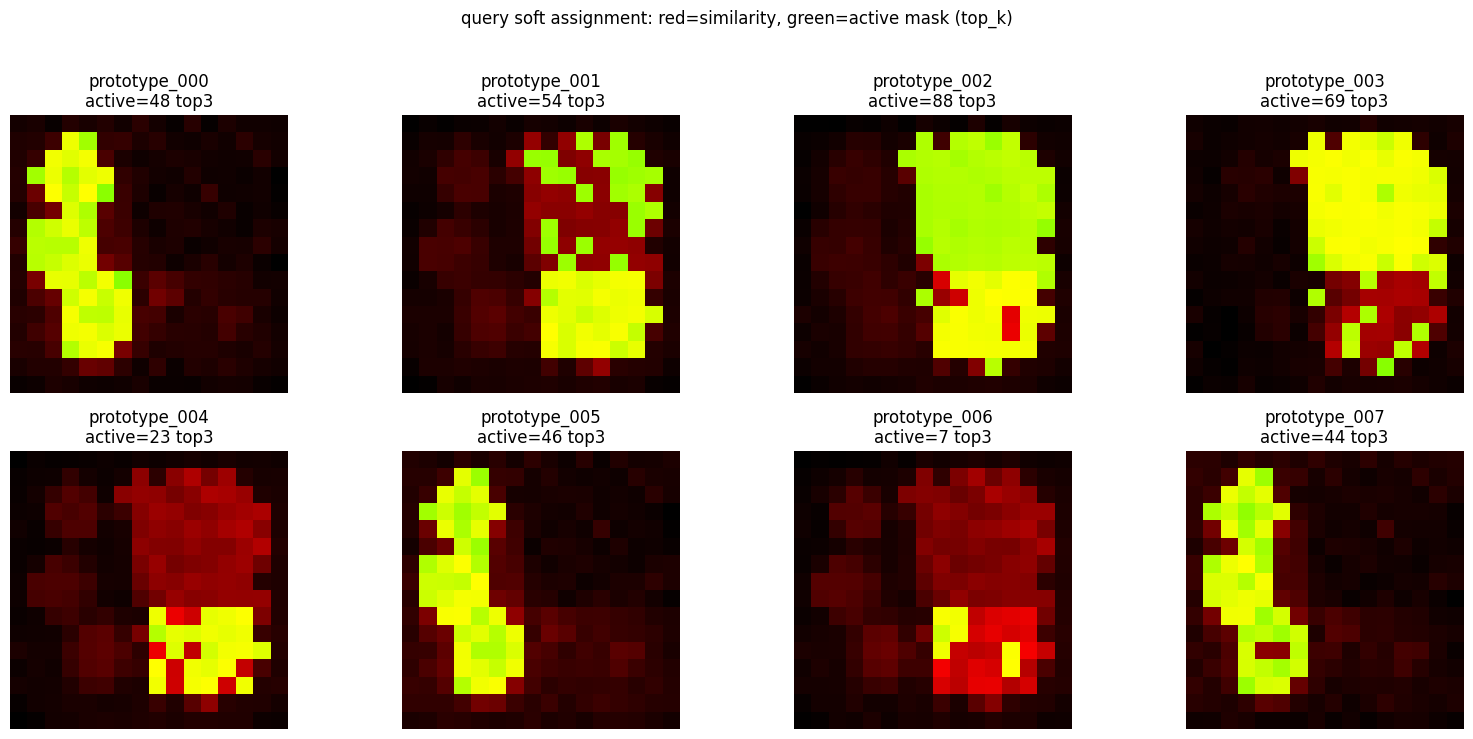

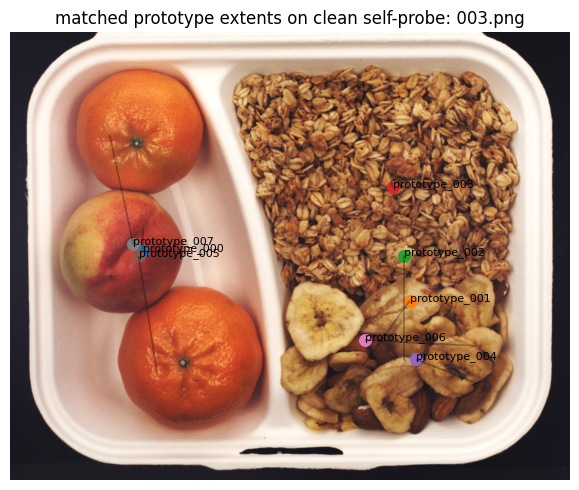

,prototype_id,matching_cost,unmatched_query_mass,unmatched_memory_mass,matched_instance_count,matched_instance_count_per_image,expected_instance_count,instance_count_diff,active_patch_count,plan_mass
0,prototype_000,0.143909,0.099191,0.099191,9,1.800000,1.800000,0.0,48,0.900809
1,prototype_001,0.262813,0.150806,0.150806,7,2.333333,2.333333,0.0,54,0.849194
2,prototype_002,0.270147,0.162512,0.162512,6,1.200000,1.200000,0.0,88,0.837488
3,prototype_003,0.143055,0.086447,0.086447,5,1.000000,1.000000,0.0,69,0.913553
4,prototype_004,0.219440,0.117346,0.117346,4,2.000000,2.000000,0.0,23,0.882654
5,prototype_005,0.207546,0.130002,0.130002,4,1.000000,1.000000,0.0,46,0.869998
6,prototype_006,0.220148,0.121054,0.121054,2,1.000000,1.000000,0.0,7,0.878946
7,prototype_007,0.248913,0.145896,0.145896,2,1.000000,1.000000,0.0,44,0.854104


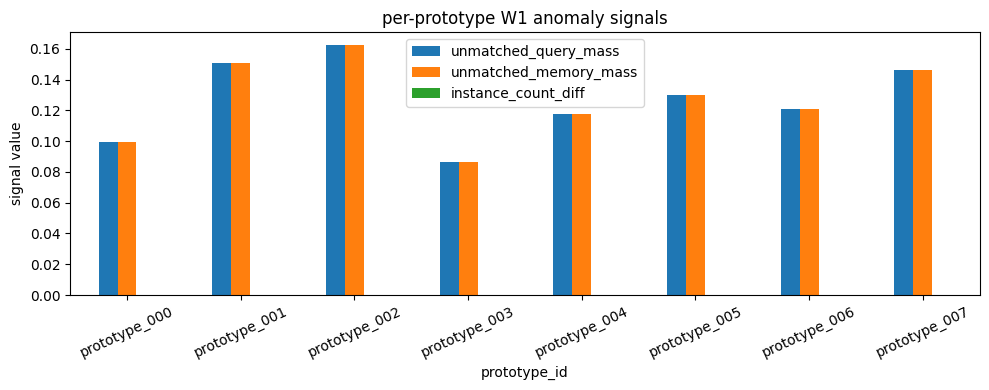

,prototype_i,prototype_j,mahalanobis
0,prototype_000,prototype_001,1.263153
1,prototype_000,prototype_002,1.711359
2,prototype_000,prototype_003,0.221887
3,prototype_000,prototype_004,2.742547
4,prototype_000,prototype_005,2.573736
5,prototype_000,prototype_006,3.424048
6,prototype_000,prototype_007,12.657870
7,prototype_001,prototype_002,1.538853
8,prototype_001,prototype_003,2.014631
9,prototype_001,prototype_004,3.411220


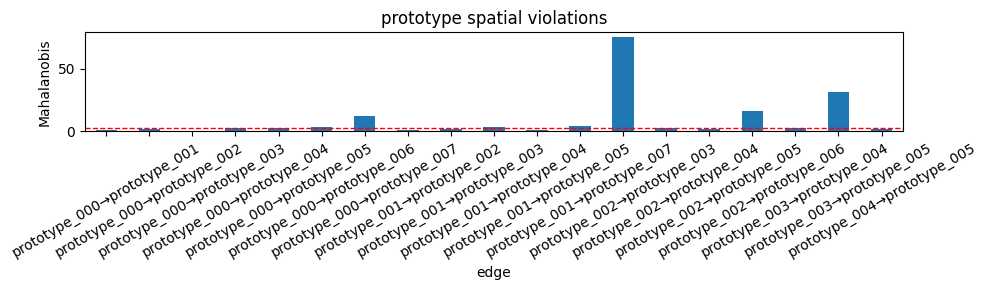

In [8]:
def cosine_matrix(left: np.ndarray, right: np.ndarray) -> np.ndarray:
    left = left.astype(np.float32)
    right = right.astype(np.float32)
    left_norm = left / np.maximum(np.linalg.norm(left, axis=1, keepdims=True), 1e-6)
    right_norm = right / np.maximum(np.linalg.norm(right, axis=1, keepdims=True), 1e-6)
    return left_norm @ right_norm.T


def prototype_threshold(entry, quantile: float) -> float:
    if quantile in entry.within_sim_quantiles:
        return float(entry.within_sim_quantiles[quantile])
    return float(entry.within_sim_quantiles.get(0.20, -1.0))


def active_mask_for_prototype(similarity: np.ndarray, proto_index: int, prototype_id: str) -> tuple[np.ndarray, str]:
    if matching_config.assignment_mode == 'top_k':
        k = max(1, min(int(matching_config.top_k_prototypes), similarity.shape[1]))
        top_indices = np.argsort(-similarity, axis=1)[:, :k]
        active = np.any(top_indices == proto_index, axis=1)
        if matching_config.min_assignment_similarity is not None:
            active &= similarity[:, proto_index] >= float(matching_config.min_assignment_similarity)
        return active, f'top{k}'
    threshold = prototype_threshold(memory.prototypes[prototype_id], matching_config.soft_assign_quantile)
    return similarity[:, proto_index] > threshold, f'tau={threshold:.2f}'

prototype_ids = list(memory.prototypes)
prototype_centroid_matrix = np.stack([memory.prototypes[pid].centroid for pid in prototype_ids], axis=0)
query_similarity = cosine_matrix(query_patch_features, prototype_centroid_matrix)
query_grid_shape = query_feature_map.shape[:2]
query_image = np.asarray(Image.open(clean_image_path(PROBE_SAMPLE_ID)).convert('RGB'))

num_cols = min(4, max(1, len(prototype_ids)))
num_rows = int(math.ceil(len(prototype_ids) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3.6 * num_rows))
axes = np.asarray(axes).reshape(-1)
for proto_index, prototype_id in enumerate(prototype_ids):
    entry = memory.prototypes[prototype_id]
    sim_grid = query_similarity[:, proto_index].reshape(query_grid_shape)
    active_flat, assignment_label = active_mask_for_prototype(query_similarity, proto_index, prototype_id)
    active = active_flat.reshape(query_grid_shape)
    panel = np.zeros((*query_grid_shape, 3), dtype=np.float32)
    norm_sim = (sim_grid - sim_grid.min()) / max(float(sim_grid.max() - sim_grid.min()), 1e-6)
    panel[..., 0] = norm_sim
    panel[..., 1] = active.astype(np.float32)
    axes[proto_index].imshow(panel)
    axes[proto_index].set_title(f'{prototype_id}\nactive={active.sum()} {assignment_label}')
    axes[proto_index].axis('off')
for ax in axes[len(prototype_ids):]:
    ax.axis('off')
fig.suptitle(f'query soft assignment: red=similarity, green=active mask ({matching_config.assignment_mode})', y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.imshow(query_image)
for prototype_id, proto_result in result.per_prototype.items():
    if proto_result.matched_extent is None:
        continue
    memory_center = prototype_centroids.get(prototype_id)
    query_center = proto_result.matched_extent
    if memory_center is None:
        continue
    ax.scatter(query_center[0] * query_image.shape[1], query_center[1] * query_image.shape[0], s=70, label=prototype_id)
    ax.text(query_center[0] * query_image.shape[1], query_center[1] * query_image.shape[0], prototype_id, fontsize=8)
    ax.arrow(
        memory_center[0] * query_image.shape[1],
        memory_center[1] * query_image.shape[0],
        (query_center[0] - memory_center[0]) * query_image.shape[1],
        (query_center[1] - memory_center[1]) * query_image.shape[0],
        width=1.0,
        alpha=0.25,
        length_includes_head=True,
    )
ax.set_title(f'matched prototype extents on clean self-probe: {PROBE_SAMPLE_ID}')
ax.axis('off')
plt.tight_layout()
plt.show()

signal_rows = []
for prototype_id, proto_result in result.per_prototype.items():
    signal_rows.append(
        {
            'prototype_id': prototype_id,
            'matching_cost': proto_result.matching_cost,
            'unmatched_query_mass': proto_result.unmatched_query_mass,
            'unmatched_memory_mass': proto_result.unmatched_memory_mass,
            'matched_instance_count': proto_result.matched_instance_count,
            'matched_instance_count_per_image': proto_result.matched_instance_count_per_image,
            'expected_instance_count': proto_result.expected_instance_count,
            'instance_count_diff': proto_result.instance_count_diff,
            'active_patch_count': proto_result.debug.get('active_patch_count', 0),
            'plan_mass': proto_result.debug.get('plan_mass', 0.0),
        }
    )
signal_df = pd.DataFrame(signal_rows)
display(signal_df)
if not signal_df.empty:
    ax = signal_df.set_index('prototype_id')[['unmatched_query_mass', 'unmatched_memory_mass', 'instance_count_diff']].plot(
        kind='bar', figsize=(10, 4)
    )
    ax.set_title('per-prototype W1 anomaly signals')
    ax.set_ylabel('signal value')
    ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

spatial_debug = result.debug.get('spatial', {})
skipped_edges = spatial_debug.get('skipped_edges', [])
if skipped_edges:
    skipped_edge_df = pd.DataFrame(skipped_edges)
    display(skipped_edge_df.groupby('reason').size().reset_index(name='count'))
else:
    skipped_edge_df = pd.DataFrame()

spatial_violation_df = pd.DataFrame([
    {'prototype_i': left, 'prototype_j': right, 'edge_error': value}
    for (left, right), value in result.spatial_violations.items()
])
display(spatial_violation_df)
if not spatial_violation_df.empty:
    ax = spatial_violation_df.assign(edge=spatial_violation_df['prototype_i'] + '→' + spatial_violation_df['prototype_j']).set_index('edge')['edge_error'].plot(
        kind='bar', figsize=(10, 3)
    )
    ax.axhline(matching_config.spatial_edge_cap, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'required-role spatial violations ({matching_config.spatial_signal_mode})')
    ax.set_ylabel('clipped normalized edge error')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    ax.imshow(query_image)
    values = spatial_violation_df['edge_error'].to_numpy(dtype=float)
    value_max = max(float(matching_config.spatial_edge_cap), float(values.max()), 1e-6)
    for _, row in spatial_violation_df.iterrows():
        left_id = str(row['prototype_i'])
        right_id = str(row['prototype_j'])
        left_extent = result.per_prototype[left_id].matched_extent
        right_extent = result.per_prototype[right_id].matched_extent
        if left_extent is None or right_extent is None:
            continue
        value = float(row['edge_error'])
        color = plt.cm.magma(min(value / value_max, 1.0))
        x1, y1 = left_extent[0] * query_image.shape[1], left_extent[1] * query_image.shape[0]
        x2, y2 = right_extent[0] * query_image.shape[1], right_extent[1] * query_image.shape[0]
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.5 + 2.5 * min(value / value_max, 1.0), alpha=0.85)
        ax.scatter([x1, x2], [y1, y2], color=[color, color], s=35)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, f'{left_id[-3:]}→{right_id[-3:]}\n{value:.2f}', color='white', fontsize=7)
    ax.set_title('required-role edge violation map on query image')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


## Cell Role: W1 Acceptance Check

스펙 §5.4 기준으로 clean self-probe sanity check를 자동 평가한다. FAIL이면 아직 W2로 넘어가지 않는다.


In [9]:
from math import comb


def all_signals_finite(decomposition) -> bool:
    values = [
        decomposition.signal_1_total,
        decomposition.signal_2_total,
        decomposition.signal_3_total,
        decomposition.signal_4_total,
        decomposition.total,
    ]
    values.extend(decomposition.spatial_violations.values())
    for proto_result in decomposition.per_prototype.values():
        values.extend([
            proto_result.query_mass,
            proto_result.memory_mass,
            proto_result.matching_cost,
            proto_result.unmatched_query_mass,
            proto_result.unmatched_memory_mass,
            proto_result.instance_count_diff,
        ])
    return bool(np.all(np.isfinite(np.asarray(values, dtype=np.float64))))

num_proto_pairs = comb(len(memory.prototypes), 2) if len(memory.prototypes) >= 2 else 0
total_query_mass = max(1.0, sum(value.query_mass for value in result.per_prototype.values()))
total_memory_mass = max(1.0, sum(value.memory_mass for value in result.per_prototype.values()))
spatial_values = list(result.spatial_violations.values())
checks = {
    'memory has at least 5 prototypes': len(memory.prototypes) >= 5,
    'every prototype has at least one instance': all(len(p.instances) >= 1 for p in memory.prototypes.values()),
    'spatial graph covers >= 50% of prototype pairs': (len(memory.spatial_graph) / max(1, num_proto_pairs)) >= 0.5,
    'signal_1 ratio < 0.20': result.signal_1_total / total_query_mass < 0.20,
    'signal_2 ratio < 0.20': result.signal_2_total / total_memory_mass < 0.20,
    'signal_3 per prototype avg < 0.5': result.signal_3_total / max(1, len(memory.prototypes)) < 0.5,
    'signal_4 avg < 3.0': (float(np.mean(spatial_values)) < 3.0) if spatial_values else True,
    'no NaN in any signal': all_signals_finite(result),
}
check_df = pd.DataFrame([
    {'check': name, 'passed': bool(passed)}
    for name, passed in checks.items()
])
display(check_df)
if check_df['passed'].all():
    print('W1 PASS: memory build and clean self-probe are ready for W2 spec.')
else:
    print('W1 NOT READY: inspect failed checks before extending to shifted/anomaly evaluation.')


,check,passed
0,memory has at least 5 prototypes,True
1,every prototype has at least one instance,True
2,spatial graph covers >= 50% of prototype pairs,True
3,signal_1 ratio < 0.20,True
4,signal_2 ratio < 0.20,True
5,signal_3 per prototype avg < 0.5,True
6,signal_4 avg < 3.0,False
7,no NaN in any signal,True


W1 NOT READY: inspect failed checks before extending to shifted/anomaly evaluation.
